# SMBH Mass Ratio Parameter Sweep

This notebook studies how the SMBH mass ratio changes the binary hardening driven by the CDM spike. The primary SMBH mass is fixed and the secondary mass is varied through `q = M_2 / M_1`.

The diagnostic quantity is the SMBH separation as a function of time. A lower final separation means that the CDM spike extracted more orbital energy before becoming depleted.

Scanned parameter: SMBH mass ratio `q`.


# Imports and Global Parameters

Define the binary, units, integration time, Schwarzschild radius, and the array of parameter values used in the sweep.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

from cdm_spike_utils import (
    add_volume_uniform_spike,
    apply_publication_style,
    configure_smbh_collisions,
    create_smbh_binary,
    moving_average,
    plot_parameter_sweep,
    schwarzschild_radius_au,
    separation_history,
)

M_1 = 3e9
R_sch = schwarzschild_radius_au(M_1)
print(f"The Schwarzschild radius is {R_sch} AU")

# Simulation parameters.
N_years = 20000
N_frames = 600
t_array = np.linspace(0, N_years, N_frames)
Delta_time = N_years / N_frames
N_sweep = 20
avg_distance_tot = []

# Define the CDM spike.
M_spike = 0.2 * M_1
N_particles = 80
radius_spike = 400000

q = np.linspace(0.2, 1, N_sweep)


The Schwarzschild radius is 59.238711673042346 AU


# Run the Sweep

For each parameter value, a new `rebound` simulation is initialized. The CDM particles are generated with the same random seed so differences between curves mainly reflect the scanned parameter rather than a different random realization.


In [2]:
for m in trange(len(q), desc="Processing"):
    sim, black_hole_1, black_hole_2, M_2, M_total = create_smbh_binary(M_1, q=q[m])
    sim.softening = R_sch

    m_single_dm = add_volume_uniform_spike(
        sim,
        n_particles=N_particles,
        total_spike_mass=M_spike,
        m_central=M_total,
        r_min=1000,
        r_max=radius_spike,
        seed=0,
    )

    print(f"Generated {N_particles} CDM particles with mass {m_single_dm:.2e} Msun each.")
    configure_smbh_collisions(sim, R_sch, r_secondary=q[m] * R_sch, softening=False)
    bh_distance = separation_history(sim, black_hole_1, black_hole_2, N_frames, Delta_time)
    avg_distance_tot.append(moving_average(bh_distance, window=50))

    print(f'Simulation for q={q[m]:.3f} completed')


Processing:   0%|          | 0/20 [00:00<?, ?it/s]

Generated 80 CDM particles with mass 7.50e+06 Msun each.


Processing:   5%|▌         | 1/20 [00:03<01:04,  3.40s/it]

Simulation for q=0.200 completed
Generated 80 CDM particles with mass 7.50e+06 Msun each.


Processing:  10%|█         | 2/20 [00:06<00:58,  3.25s/it]

...

Simulation for q=0.916 completed
Generated 80 CDM particles with mass 7.50e+06 Msun each.


Processing:  95%|█████████▌| 19/20 [00:59<00:02,  2.98s/it]

Simulation for q=0.958 completed
Generated 80 CDM particles with mass 7.50e+06 Msun each.


Processing: 100%|██████████| 20/20 [01:01<00:00,  3.09s/it]

Simulation for q=1.000 completed


# Plot Separation Curves

The color of each curve encodes the scanned parameter. The late-time value of each curve gives the stalling distance for that run.


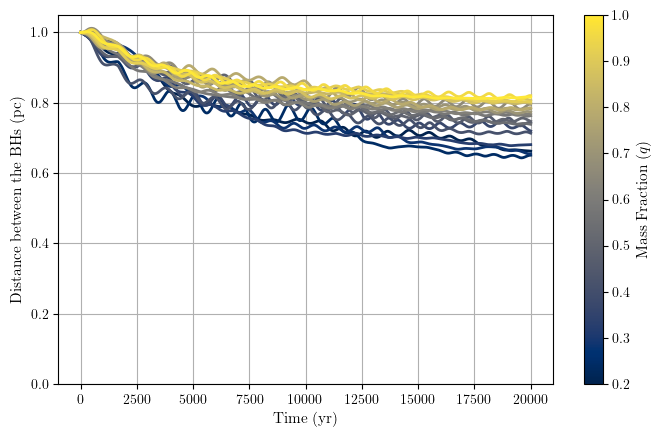

In [3]:
apply_publication_style(use_tex=True)

fig1, ax1d = plot_parameter_sweep(
    t_array=t_array,
    distance_histories=avg_distance_tot,
    parameter_values=q,
    colorbar_label='Mass Fraction ($q$)',
    cmap_name='cividis',
    output_path=f'Distance_vs_time_scanning_q_N={N_particles}_Nscanning={N_sweep}_softened.pdf',
)

plt.show()


# Save Numerical Results

Store the separation histories in a compressed NumPy file so they can be reused for fitting or plotting without rerunning the full sweep.


In [4]:
np.savez(f'datos_d_vs_t_softened_sweep_q_N={N_particles}.npz', avg_distance_tot = avg_distance_tot)
